# Multi-City Code Enforcement Financial Analysis

**Data Strategy**: Using legacy clean data now, designed for easy switch to schema-extracted data later.

**Cities Analyzed**:
-  **Margate**: 741 violations (complete dataset)
-  **Boca Raton**: Processed violations
-  **Pompano Beach**: Processed violations  
-  **Wilton Manor**: Processed violations

**Key Metrics**:
- Violation frequency by city
- Financial impact analysis
- Temporal trends
- Geographic patterns
- Risk assessment scores

In [1]:
# ANALYSIS CONFIGURATION
# Professional formatting preferences

import warnings
warnings.filterwarnings('ignore')

# Display settings
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Path display settings - control path visibility
from pathlib import Path
import os

# Professional output preferences
PROFESSIONAL_MODE = True
SHOW_FULL_PATHS = False  # Set to True if you want to see full paths

def print_path(label, path):
    """Print path only if SHOW_FULL_PATHS is True"""
    if SHOW_FULL_PATHS:
        print(f"{label}: {path}")
    else:
        print(f"{label}: [hidden]")

print("Configuration loaded:")
print(f"- Professional mode: {PROFESSIONAL_MODE}")
print(f"- Show full paths: {SHOW_FULL_PATHS}")
print("- Display options optimized")
print("- Warnings suppressed")

Configuration loaded:
- Professional mode: True
- Show full paths: False
- Display options optimized
- Warnings suppressed


## Data Loading & Standardization

**Design**: Standardized data loading that works with both legacy and schema data

In [20]:
def load_city_data(city_name: str, use_schema: bool = False) -> pd.DataFrame:
    """
    Load city data from either legacy clean files or schema-extracted files
    
    Args:
        city_name: Name of city (margate, boca_raton, etc.)
        use_schema: If True, try schema data first, fallback to legacy
        
    Returns:
        Standardized DataFrame with consistent column names
    """
    
    df = None
    data_source = "unknown"
    
    # Try schema data first if requested
    if use_schema:
        schema_files = list((SCHEMA_DATA_DIR / city_name).glob("*_clean.csv"))
        if schema_files:
            try:
                df = pd.read_csv(schema_files[0])
                data_source = "schema"
                print(f"📊 {city_name}: Loaded {len(df)} rows from schema data")
            except Exception as e:
                print(f"⚠️  Schema data failed for {city_name}: {e}")
    
    # Fallback to legacy data
    if df is None:
        legacy_patterns = [
            f"{city_name}_clean.csv",
            f"{city_name}_processed.csv", 
            f"{city_name.replace('_', ' ').title().replace(' ', '')}_clean.csv"
        ]
        
        for pattern in legacy_patterns:
            legacy_file = CLEAN_DATA_DIR / pattern
            if legacy_file.exists():
                try:
                    df = pd.read_csv(legacy_file)
                    
                    # Special handling for Wilton Manor - fix header issues
                    if city_name == 'wilton_manor' and '0' in df.columns:
                        print(f"🔧 {city_name}: Fixing header structure...")
                        
                        # Check if first row contains headers
                        if df.iloc[0, 0] == 'File#':
                            # Use first row as headers and drop it
                            new_headers = df.iloc[0].tolist()
                            df.columns = new_headers
                            df = df.drop(0).reset_index(drop=True)
                            print(f"   Fixed headers: {new_headers}")
                    
                    data_source = "legacy"
                    print(f"📋 {city_name}: Loaded {len(df)} rows from legacy data")
                    break
                except Exception as e:
                    print(f"⚠️  Failed to load {legacy_file}: {e}")
    
    if df is None:
        print(f"❌ No data found for {city_name}")
        return pd.DataFrame()
    
    # Standardize column names for consistent analysis
    df = standardize_columns(df, data_source, city_name)
    df['city'] = city_name.replace('_', ' ').title()
    df['data_source'] = data_source
    
    return df

def standardize_columns(df: pd.DataFrame, source: str, city_name: str = "") -> pd.DataFrame:
    """
    Standardize column names for consistent analysis
    """
    
    column_mapping = {}
    
    if source == "schema":
        # Schema data has clean names already
        column_mapping = {
            'CASE NUMBER': 'violation_id',
            'CASE TYPE': 'violation_type', 
            'ADDRESS': 'address',
            'STATUS': 'status',
            'DATE OPENED': 'date_opened',
            'DAYS ACTIVE': 'days_active',
            'LAST ACTION': 'last_action',
            'NEXT ACTION': 'next_action',
            'RESULT DATE': 'result_date',
            'DUE DATE': 'due_date'
        }
    else:
        # Legacy data needs cleaning - different patterns for different cities
        if city_name == 'wilton_manor':
            # Wilton Manor has specific column names after header fix
            column_mapping = {
                'File#': 'violation_id',
                'Violation': 'violation_type',
                'Address': 'address',
                'Status': 'status',
                'Open Date': 'date_opened'
            }
        else:
            # Standard legacy mapping for other cities
            column_mapping = {
                'violation_id_raw': 'violation_id',
                'violation_description_raw': 'violation_type',
                'address_raw': 'address', 
                'case_status_raw': 'status',
                'opened_date_raw': 'date_opened',
                'days_active_raw': 'days_active',
                'last_action_raw': 'last_action',
                'next_action_raw': 'next_action',
                'result_date_raw': 'result_date',
                'due_date_raw': 'due_date',
                'closed_date_raw': 'date_closed'
            }
    
    # Apply mappings
    df_clean = df.copy()
    for old_col, new_col in column_mapping.items():
        if old_col in df_clean.columns:
            df_clean[new_col] = df_clean[old_col]
    
    return df_clean

print("✅ Data loading functions updated with Wilton Manor header fix")
print("🔄 Designed for easy switching between legacy and schema data")

✅ Data loading functions updated with Wilton Manor header fix
🔄 Designed for easy switching between legacy and schema data


In [3]:
def load_city_data(city_name: str, use_schema: bool = False) -> pd.DataFrame:
    """
    Load city data from either legacy clean files or schema-extracted files
    
    Args:
        city_name: Name of city (margate, boca_raton, etc.)
        use_schema: If True, try schema data first, fallback to legacy
        
    Returns:
        Standardized DataFrame with consistent column names
    """
    
    df = None
    data_source = "unknown"
    
    # Try schema data first if requested
    if use_schema:
        schema_files = list((SCHEMA_DATA_DIR / city_name).glob("*_clean.csv"))
        if schema_files:
            try:
                df = pd.read_csv(schema_files[0])
                data_source = "schema"
                print(f"📊 {city_name}: Loaded {len(df)} rows from schema data")
            except Exception as e:
                print(f"⚠️  Schema data failed for {city_name}: {e}")
    
    # Fallback to legacy data
    if df is None:
        legacy_patterns = [
            f"{city_name}_clean.csv",
            f"{city_name}_processed.csv", 
            f"{city_name.replace('_', ' ').title().replace(' ', '')}_clean.csv"
        ]
        
        for pattern in legacy_patterns:
            legacy_file = CLEAN_DATA_DIR / pattern
            if legacy_file.exists():
                try:
                    df = pd.read_csv(legacy_file)
                    data_source = "legacy"
                    print(f"📋 {city_name}: Loaded {len(df)} rows from legacy data")
                    break
                except Exception as e:
                    print(f"⚠️  Failed to load {legacy_file}: {e}")
    
    if df is None:
        print(f"❌ No data found for {city_name}")
        return pd.DataFrame()
    
    # Standardize column names for consistent analysis
    df = standardize_columns(df, data_source)
    df['city'] = city_name.replace('_', ' ').title()
    df['data_source'] = data_source
    
    return df

def standardize_columns(df: pd.DataFrame, source: str) -> pd.DataFrame:
    """
    Standardize column names for consistent analysis
    """
    
    column_mapping = {}
    
    if source == "schema":
        # Schema data has clean names already
        column_mapping = {
            'CASE NUMBER': 'violation_id',
            'CASE TYPE': 'violation_type', 
            'ADDRESS': 'address',
            'STATUS': 'status',
            'DATE OPENED': 'date_opened',
            'DAYS ACTIVE': 'days_active',
            'LAST ACTION': 'last_action',
            'NEXT ACTION': 'next_action',
            'RESULT DATE': 'result_date',
            'DUE DATE': 'due_date'
        }
    else:
        # Legacy data needs cleaning
        column_mapping = {
            'violation_id_raw': 'violation_id',
            'violation_description_raw': 'violation_type',
            'address_raw': 'address', 
            'case_status_raw': 'status',
            'opened_date_raw': 'date_opened',
            'days_active_raw': 'days_active',
            'last_action_raw': 'last_action',
            'next_action_raw': 'next_action',
            'result_date_raw': 'result_date',
            'due_date_raw': 'due_date',
            'closed_date_raw': 'date_closed'
        }
    
    # Apply mappings
    df_clean = df.copy()
    for old_col, new_col in column_mapping.items():
        if old_col in df_clean.columns:
            df_clean[new_col] = df_clean[old_col]
    
    return df_clean

print("✅ Data loading functions defined")
print("🔄 Designed for easy switching between legacy and schema data")

✅ Data loading functions defined
🔄 Designed for easy switching between legacy and schema data


## Load All City Data

Loading all available city data with automatic fallback from schema to legacy data.

In [21]:
# Load all city data
cities = ['margate', 'pompano_beach', 'wilton_manor'] ##only clean data cities
city_data = {}
total_violations = 0

print(" LOADING MULTI-CITY VIOLATION DATA")
print("=" * 50)

for city in cities:
    df = load_city_data(city, use_schema=False)  # Using legacy for deadline
    if not df.empty:
        city_data[city] = df
        total_violations += len(df)
        
        # Quick data quality check
        key_fields = ['violation_id', 'address', 'status']
        completeness = {}
        for field in key_fields:
            if field in df.columns:
                completeness[field] = df[field].notna().sum() / len(df) * 100
        
        print(f"   Data quality: {completeness}")

print(f"\n SUMMARY:")
print(f"   Cities loaded: {len(city_data)}")
print(f"   Total violations: {total_violations:,}")
print(f"   Data sources: {[df['data_source'].iloc[0] for df in city_data.values()]}")

if len(city_data) == 0:
    print("❌ No data loaded! Check file paths.")
else:
    print(f" Ready for financial analysis!")

 LOADING MULTI-CITY VIOLATION DATA
📋 margate: Loaded 741 rows from legacy data
   Data quality: {'violation_id': np.float64(100.0), 'address': np.float64(90.55330634278003), 'status': np.float64(100.0)}
📋 pompano_beach: Loaded 389 rows from legacy data
   Data quality: {'violation_id': np.float64(95.11568123393316), 'address': np.float64(97.17223650385604), 'status': np.float64(95.11568123393316)}
🔧 wilton_manor: Fixing header structure...
   Fixed headers: ['File#', 'Violation', 'Address', 'Open Date', 'Status', np.int64(4), 'wilton_Code_Violation_to_March_2024-30p.json', 'Wilton Manor']
📋 wilton_manor: Loaded 567 rows from legacy data
   Data quality: {'violation_id': np.float64(100.0), 'address': np.float64(100.0), 'status': np.float64(100.0)}

 SUMMARY:
   Cities loaded: 3
   Total violations: 1,697
   Data sources: ['legacy', 'legacy', 'legacy']
 Ready for financial analysis!


##  Financial Impact Analysis

Analyzing the financial implications of code enforcement violations across all cities.

In [22]:
# Combine all city data for analysis
if city_data:
    all_violations = pd.concat(city_data.values(), ignore_index=True)
    
    print(f" MULTI-CITY VIOLATION ANALYSIS")
    print(f" Total violations: {len(all_violations):,}")
    print(f" Cities: {all_violations['city'].unique()}")
    
    # Violations by city
    city_counts = all_violations['city'].value_counts()
    print(f"\n VIOLATIONS BY CITY:")
    for city, count in city_counts.items():
        percentage = count / len(all_violations) * 100
        print(f"   {city}: {count:,} violations ({percentage:.1f}%)")
    
    # Status distribution
    if 'status' in all_violations.columns:
        status_counts = all_violations['status'].value_counts()
        print(f"\n STATUS DISTRIBUTION:")
        for status, count in status_counts.head().items():
            percentage = count / len(all_violations) * 100
            print(f"   {status}: {count:,} ({percentage:.1f}%)")
            
    print(f"\n Basic analysis complete - ready for detailed financial modeling!")
else:
    print("❌ No data available for analysis")

 MULTI-CITY VIOLATION ANALYSIS
 Total violations: 1,697
 Cities: ['Margate' 'Pompano Beach' 'Wilton Manor']

 VIOLATIONS BY CITY:
   Margate: 741 violations (43.7%)
   Wilton Manor: 567 violations (33.4%)
   Pompano Beach: 389 violations (22.9%)

 STATUS DISTRIBUTION:
   ACTIVE: 864 (50.9%)
   Closed: 366 (21.6%)
   CASE CLOSED: 239 (14.1%)
   Open: 201 (11.8%)
   IN COMPLIANCE/OPEN FINES: 7 (0.4%)

 Basic analysis complete - ready for detailed financial modeling!


## Master Dataset Examination

Detailed view of the consolidated violation data structure and contents

In [9]:
# Examine the master consolidated dataset
if 'all_violations' in locals() and not all_violations.empty:
    
    print("MASTER DATASET OVERVIEW")
    print("=" * 50)
    print(f"Total rows: {len(all_violations):,}")
    print(f"Total columns: {len(all_violations.columns)}")
    print(f"Cities included: {list(all_violations['city'].unique())}")
    print(f"Date range: {all_violations.index.min()} to {all_violations.index.max()}")
    
    print(f"\nCOLUMN STRUCTURE:")
    print("-" * 30)
    for i, col in enumerate(all_violations.columns, 1):
        non_null_count = all_violations[col].notna().sum()
        completeness = (non_null_count / len(all_violations)) * 100
        print(f"{i:2d}. {col:<25} | {non_null_count:,} values ({completeness:.1f}% complete)")
    
    print(f"\nDATA TYPES:")
    print("-" * 20)
    print(all_violations.dtypes)
    
    print(f"\nFIRST 5 ROWS SAMPLE:")
    print("-" * 25)
    print(all_violations.head())
    
    print(f"\nMEMORY USAGE:")
    print("-" * 15)
    memory_usage = all_violations.memory_usage(deep=True).sum() / (1024 * 1024)  # Convert to MB
    print(f"Dataset size: {memory_usage:.2f} MB")
    
else:
    print("No master dataset found. Run the previous cell first.")

MASTER DATASET OVERVIEW
Total rows: 1,698
Total columns: 34
Cities included: ['Margate', 'Pompano Beach', 'Wilton Manor']
Date range: 0 to 1697

COLUMN STRUCTURE:
------------------------------
 1. violation_id_raw          | 1,111 values (65.4% complete)
 2. case_status_raw           | 1,111 values (65.4% complete)
 3. chunk_id                  | 1,698 values (100.0% complete)
 4. source_file               | 1,698 values (100.0% complete)
 5. Unnamed: 4                | 17 values (1.0% complete)
 6. violation_description_raw | 1,119 values (65.9% complete)
 7. address_raw               | 1,049 values (61.8% complete)
 8. opened_date_raw           | 1,111 values (65.4% complete)
 9. days_active_raw           | 1,111 values (65.4% complete)
10. last_action_raw           | 1,088 values (64.1% complete)
11. next_action_raw           | 702 values (41.3% complete)
12. closed_date_raw           | 224 values (13.2% complete)
13. result_date_raw           | 680 values (40.0% complete)
14. due_

## Export Master Dataset to CSV

Save the consolidated dataset for external examination and backup

In [8]:
# Export consolidated dataset to CSV file
if 'all_violations' in locals() and not all_violations.empty:
    
    # Create output filename with timestamp 
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f"master_violations_dataset_{timestamp}.csv"
    output_path = ROOT / "clean_data" / output_filename
    
    # Export to CSV
    all_violations.to_csv(output_path, index=False)
    
    print("CSV EXPORT COMPLETE")
    print("=" * 30)
    print(f"File: {output_filename}")
    print(f"Location: {output_path}")
    print(f"Records exported: {len(all_violations):,}")
    print(f"Columns exported: {len(all_violations.columns)}")
    print(f"File size: {output_path.stat().st_size / (1024*1024):.2f} MB")
    
    # Show what was exported
    print(f"\nEXPORTED COLUMNS:")
    print("-" * 20)
    for i, col in enumerate(all_violations.columns, 1):
        print(f"{i:2d}. {col}")
        
    print(f"\nCITIES INCLUDED:")
    print("-" * 20)
    city_counts = all_violations['city'].value_counts()
    for city, count in city_counts.items():
        print(f"{city}: {count:,} violations")
    
    print(f"\nYou can now open this CSV file in Excel, Google Sheets, or any spreadsheet application!")
    
else:
    print("No master dataset found. Run the data loading cells first.")

CSV EXPORT COMPLETE
File: master_violations_dataset_20251110_112857.csv
Location: c:\Users\edilm\OneDrive\Desktop\Edilma Projects\LandingAI-Hack\coderisk-sf\clean_data\master_violations_dataset_20251110_112857.csv
Records exported: 1,698
Columns exported: 34
File size: 0.43 MB

EXPORTED COLUMNS:
--------------------
 1. violation_id_raw
 2. case_status_raw
 3. chunk_id
 4. source_file
 5. Unnamed: 4
 6. violation_description_raw
 7. address_raw
 8. opened_date_raw
 9. days_active_raw
10. last_action_raw
11. next_action_raw
12. closed_date_raw
13. result_date_raw
14. due_date_raw
15. city
16. violation_id
17. violation_type
18. address
19. status
20. date_opened
21. days_active
22. last_action
23. next_action
24. result_date
25. due_date
26. date_closed
27. data_source
28. violation_code_raw
29. case_disposition_raw
30. 0
31. 1
32. 2
33. 3
34. 4

CITIES INCLUDED:
--------------------
Margate: 741 violations
Wilton Manor: 568 violations
Pompano Beach: 389 violations

You can now open thi

## Violation Type Analysis

Exploring unique violation types across all cities to identify investment opportunity patterns

In [10]:
# Analyze violation types across all cities
if 'all_violations' in locals() and not all_violations.empty:
    
    print("VIOLATION TYPE ANALYSIS")
    print("=" * 50)
    
    # Overall violation type statistics
    if 'violation_type' in all_violations.columns:
        violation_counts = all_violations['violation_type'].value_counts()
        
        print(f"Total unique violation types: {len(violation_counts)}")
        print(f"Most common violations across all cities:")
        print("-" * 40)
        
        # Show top 15 most common violations
        for i, (violation, count) in enumerate(violation_counts.head(15).items(), 1):
            percentage = (count / len(all_violations)) * 100
            print(f"{i:2d}. {violation:<50} | {count:4d} ({percentage:5.1f}%)")
        
        # Show violation types by city
        print(f"\nVIOLATION TYPES BY CITY:")
        print("=" * 40)
        
        for city in all_violations['city'].unique():
            city_data = all_violations[all_violations['city'] == city]
            city_violations = city_data['violation_type'].value_counts()
            
            print(f"\n{city.upper()}:")
            print(f"  Unique violation types: {len(city_violations)}")
            print(f"  Top 5 violations:")
            
            for i, (violation, count) in enumerate(city_violations.head(5).items(), 1):
                percentage = (count / len(city_data)) * 100
                print(f"    {i}. {violation:<40} | {count:4d} ({percentage:4.1f}%)")
        
        # Identify potential investment categories
        print(f"\nPOTENTIAL INVESTMENT CATEGORIES:")
        print("=" * 40)
        
        # Keywords that might indicate different investment opportunities
        building_keywords = ['building', 'structure', 'construction', 'permit', 'zoning']
        maintenance_keywords = ['maintenance', 'repair', 'property', 'yard', 'exterior']
        safety_keywords = ['safety', 'fire', 'electrical', 'plumbing', 'code']
        
        building_violations = []
        maintenance_violations = []
        safety_violations = []
        other_violations = []
        
        for violation in violation_counts.index:
            violation_lower = str(violation).lower()
            
            if any(keyword in violation_lower for keyword in building_keywords):
                building_violations.append((violation, violation_counts[violation]))
            elif any(keyword in violation_lower for keyword in maintenance_keywords):
                maintenance_violations.append((violation, violation_counts[violation]))
            elif any(keyword in violation_lower for keyword in safety_keywords):
                safety_violations.append((violation, violation_counts[violation]))
            else:
                other_violations.append((violation, violation_counts[violation]))
        
        print(f"BUILDING/DEVELOPMENT Related: {len(building_violations)} types")
        if building_violations:
            for violation, count in sorted(building_violations, key=lambda x: x[1], reverse=True)[:5]:
                print(f"  - {violation} ({count})")
        
        print(f"\nMAINTENANCE/PROPERTY Related: {len(maintenance_violations)} types")
        if maintenance_violations:
            for violation, count in sorted(maintenance_violations, key=lambda x: x[1], reverse=True)[:5]:
                print(f"  - {violation} ({count})")
        
        print(f"\nSAFETY/CODE Related: {len(safety_violations)} types")
        if safety_violations:
            for violation, count in sorted(safety_violations, key=lambda x: x[1], reverse=True)[:5]:
                print(f"  - {violation} ({count})")
        
        print(f"\nOTHER: {len(other_violations)} types")
        if other_violations:
            for violation, count in sorted(other_violations, key=lambda x: x[1], reverse=True)[:5]:
                print(f"  - {violation} ({count})")
        
        print(f"\nREADY FOR INVESTMENT CATEGORIZATION!")
        print("Review the violation types above to decide investment opportunity categories.")
        
    else:
        print("No violation_type column found in dataset")
        print("Available columns:", list(all_violations.columns))
        
else:
    print("No master dataset found. Run the data loading cells first.")

VIOLATION TYPE ANALYSIS
Total unique violation types: 169
Most common violations across all cities:
----------------------------------------
 1. WORK WITHOUT PERMIT-BUILDING                       |  389 ( 22.9%)
 2. 40 YEAR SAFETY INSPECTIONS                         |  155 (  9.1%)
 3. UNSAFE STRUCTURE (BLDG)                            |  100 (  5.9%)
 4. SPECIFIC VIOL; OCCUPY STUCTURE                     |   22 (  1.3%)
 5. BTR; RENTAL HOUSING                                |   21 (  1.2%)
 6. SPECIFIC VIOL; DISTUB LANDSCAP                     |   21 (  1.2%)
 7. BTR; RENTAL HOUSING INSPECTION                     |   18 (  1.1%)
 8. 50 YEAR SAFETY INSPECTIONS                         |   18 (  1.1%)
 9. PARKING; SURFACE STANDARDS                         |   17 (  1.0%)
10. NUISANCE; GRASS OR WEEDS                           |   13 (  0.8%)
11. ABANDONED VEHICLES                                 |   13 (  0.8%)
12. NUISANCE; STATE OF REPAIR                          |   13 (  0.8%)
13. REN

## Structural Risk Index (SRI) Analysis

**High-Impact Analysis #1**: Property-level risk scoring system for safety assessment and investment intelligence

**Risk Factors & Weights**:
- 40-year/50-year inspection: +3 points (aging building risk)
- Unsafe Structure (BLDG): +5 points (critical safety risk)  
- Work Without Permit: +2 points (illegal/unsafe modifications)
- Nuisance/Maintenance: +1 point (minor deterioration)
- Multiple violations same parcel: +1 each (recurring issues pattern)

**Applications**: City inspection prioritization, investor distressed property identification, insurance risk adjustment

In [23]:
# Structural Risk Index (SRI) Analysis System
import re
from collections import defaultdict

class StructuralRiskAnalyzer:
    """
    Calculate Structural Risk Index for properties based on violation patterns
    """
    
    def __init__(self, violations_data):
        self.data = violations_data.copy()
        
        # Risk scoring weights
        self.risk_weights = {
            'inspection_40_50_year': 3,    # Aging building inspections
            'unsafe_structure': 5,         # Critical structural issues
            'work_without_permit': 2,      # Unpermitted work
            'nuisance_maintenance': 1,     # Minor maintenance issues
            'multiple_violation_bonus': 1  # Extra point per additional violation at same address
        }
        
    def categorize_violation_risk(self, violation_text):
        """
        Categorize each violation into risk categories based on description
        """
        if pd.isna(violation_text):
            return 'unknown', 0
            
        violation_lower = str(violation_text).lower()
        
        # 40/50 year inspection indicators
        if any(keyword in violation_lower for keyword in ['40 year', '50 year', 'recertification', 'structural inspection']):
            return 'inspection_40_50_year', self.risk_weights['inspection_40_50_year']
        
        # Unsafe structure indicators    
        elif any(keyword in violation_lower for keyword in ['unsafe', 'structural', 'collapse', 'dangerous', 'condemned']):
            return 'unsafe_structure', self.risk_weights['unsafe_structure']
        
        # Work without permit indicators
        elif any(keyword in violation_lower for keyword in ['permit', 'unpermitted', 'unauthorized', 'illegal work']):
            return 'work_without_permit', self.risk_weights['work_without_permit']
        
        # Maintenance/nuisance indicators
        elif any(keyword in violation_lower for keyword in ['maintenance', 'repair', 'nuisance', 'property upkeep', 'exterior']):
            return 'nuisance_maintenance', self.risk_weights['nuisance_maintenance']
        
        # Default category for unmatched violations
        else:
            return 'other', 1
    
    def calculate_property_sri(self):
        """
        Calculate Structural Risk Index for each property address
        """
        
        if 'address' not in self.data.columns or 'violation_type' not in self.data.columns:
            print("Missing required columns: address and violation_type")
            return pd.DataFrame()
        
        # Group violations by address
        property_risks = defaultdict(lambda: {
            'city': '',
            'total_violations': 0,
            'risk_categories': defaultdict(int),
            'violation_details': [],
            'base_risk_score': 0,
            'multiple_violation_bonus': 0,
            'total_sri_score': 0
        })
        
        print("CALCULATING STRUCTURAL RISK INDEX")
        print("=" * 50)
        
        # Process each violation
        for _, row in self.data.iterrows():
            address = str(row.get('address', 'Unknown')).strip().upper()
            city = row.get('city', 'Unknown')
            violation_type = row.get('violation_type', 'Unknown')
            
            # Skip invalid addresses
            if address in ['UNKNOWN', 'NAN', '']:
                continue
            
            # Categorize violation risk
            risk_category, risk_points = self.categorize_violation_risk(violation_type)
            
            # Update property risk data
            property_risks[address]['city'] = city
            property_risks[address]['total_violations'] += 1
            property_risks[address]['risk_categories'][risk_category] += 1
            property_risks[address]['violation_details'].append({
                'violation_type': violation_type,
                'risk_category': risk_category,
                'risk_points': risk_points
            })
            property_risks[address]['base_risk_score'] += risk_points
        
        # Calculate final SRI scores
        sri_results = []
        
        for address, risk_data in property_risks.items():
            # Multiple violation bonus (extra point for each violation beyond the first)
            multiple_bonus = max(0, risk_data['total_violations'] - 1) * self.risk_weights['multiple_violation_bonus']
            
            # Total SRI score
            total_sri = risk_data['base_risk_score'] + multiple_bonus
            
            sri_results.append({
                'address': address,
                'city': risk_data['city'],
                'total_violations': risk_data['total_violations'],
                'base_risk_score': risk_data['base_risk_score'],
                'multiple_violation_bonus': multiple_bonus,
                'total_sri_score': total_sri,
                'inspection_40_50_violations': risk_data['risk_categories']['inspection_40_50_year'],
                'unsafe_structure_violations': risk_data['risk_categories']['unsafe_structure'],
                'work_without_permit_violations': risk_data['risk_categories']['work_without_permit'],
                'nuisance_maintenance_violations': risk_data['risk_categories']['nuisance_maintenance'],
                'other_violations': risk_data['risk_categories']['other'],
                'violation_details': risk_data['violation_details']
            })
        
        # Convert to DataFrame and sort by risk score
        sri_df = pd.DataFrame(sri_results)
        sri_df = sri_df.sort_values('total_sri_score', ascending=False)
        
        print(f"Processed {len(sri_df)} unique properties")
        print(f"Total violations analyzed: {self.data.shape[0]:,}")
        
        return sri_df
    
    def generate_sri_summary(self, sri_df):
        """
        Generate summary statistics for SRI analysis
        """
        
        if sri_df.empty:
            return {}
        
        summary = {
            'total_properties': len(sri_df),
            'total_violations': sri_df['total_violations'].sum(),
            'avg_sri_score': sri_df['total_sri_score'].mean(),
            'max_sri_score': sri_df['total_sri_score'].max(),
            'high_risk_properties': len(sri_df[sri_df['total_sri_score'] >= 8]),  # Score 8+ = high risk
            'medium_risk_properties': len(sri_df[(sri_df['total_sri_score'] >= 4) & (sri_df['total_sri_score'] < 8)]),
            'low_risk_properties': len(sri_df[sri_df['total_sri_score'] < 4])
        }
        
        # City breakdown
        city_breakdown = sri_df.groupby('city').agg({
            'total_sri_score': ['count', 'mean', 'max'],
            'total_violations': 'sum'
        }).round(2)
        
        summary['city_breakdown'] = city_breakdown
        
        return summary

# Initialize SRI analyzer if we have violation data
if 'all_violations' in locals() and not all_violations.empty:
    sri_analyzer = StructuralRiskAnalyzer(all_violations)
    print("Structural Risk Index analyzer initialized")
    print(f"Ready to analyze {len(all_violations):,} violations for SRI scoring")
else:
    print("No violation data available - run data loading cells first")

Structural Risk Index analyzer initialized
Ready to analyze 1,697 violations for SRI scoring


In [24]:
# Execute SRI Analysis and Generate Results
if 'sri_analyzer' in locals():
    
    print("EXECUTING STRUCTURAL RISK INDEX ANALYSIS")
    print("=" * 60)
    
    # Calculate SRI scores for all properties
    sri_results = sri_analyzer.calculate_property_sri()
    
    if not sri_results.empty:
        
        # Generate summary statistics
        sri_summary = sri_analyzer.generate_sri_summary(sri_results)
        
        print(f"\nSTRUCTURAL RISK INDEX SUMMARY")
        print("=" * 40)
        print(f"Total Properties Analyzed: {sri_summary['total_properties']:,}")
        print(f"Total Violations: {sri_summary['total_violations']:,}")
        print(f"Average SRI Score: {sri_summary['avg_sri_score']:.2f}")
        print(f"Maximum SRI Score: {sri_summary['max_sri_score']}")
        
        print(f"\nRISK DISTRIBUTION:")
        print(f"  High Risk (8+ points): {sri_summary['high_risk_properties']} properties")
        print(f"  Medium Risk (4-7 points): {sri_summary['medium_risk_properties']} properties") 
        print(f"  Low Risk (<4 points): {sri_summary['low_risk_properties']} properties")
        
        # Show top 10 highest risk properties
        print(f"\nTOP 10 HIGHEST RISK PROPERTIES:")
        print("-" * 50)
        
        for i, row in sri_results.head(10).iterrows():
            print(f"\n{i+1:2d}. {row['address'][:50]}")
            print(f"    City: {row['city']}")
            print(f"    SRI Score: {row['total_sri_score']} points")
            print(f"    Violations: {row['total_violations']} total")
            print(f"    Risk Breakdown: Unsafe:{row['unsafe_structure_violations']} | "
                  f"NoPermit:{row['work_without_permit_violations']} | "
                  f"Inspection:{row['inspection_40_50_violations']} | "
                  f"Maintenance:{row['nuisance_maintenance_violations']}")
        
        # City-by-city analysis
        print(f"\nSRI ANALYSIS BY CITY:")
        print("-" * 30)
        
        for city in sri_results['city'].unique():
            city_data = sri_results[sri_results['city'] == city]
            high_risk_count = len(city_data[city_data['total_sri_score'] >= 8])
            avg_score = city_data['total_sri_score'].mean()
            
            print(f"\n{city.upper()}:")
            print(f"  Properties: {len(city_data):,}")
            print(f"  Average SRI: {avg_score:.2f}")
            print(f"  High Risk Properties: {high_risk_count}")
            print(f"  Highest Risk Address: {city_data.iloc[0]['address'][:40]} (Score: {city_data.iloc[0]['total_sri_score']})")
        
        print(f"\nACTIONABLE INTELLIGENCE READY:")
        print("- Cities: Use for inspection prioritization")
        print("- Investors: Identify distressed properties")  
        print("- Insurance: Risk-based premium adjustments")
        print("- Residents: Understand neighborhood safety risks")
        
        # Save results
        output_path = ROOT / "clean_data" / "structural_risk_index_results.csv"
        sri_results.to_csv(output_path, index=False)
        print(f"\nSRI results saved to: {output_path}")
        
    else:
        print("No SRI results generated - check violation data")
        
else:
    print("SRI analyzer not initialized - run previous cell first")

EXECUTING STRUCTURAL RISK INDEX ANALYSIS
CALCULATING STRUCTURAL RISK INDEX
Processed 1089 unique properties
Total violations analyzed: 1,697

STRUCTURAL RISK INDEX SUMMARY
Total Properties Analyzed: 1,089
Total Violations: 1,616
Average SRI Score: 3.11
Maximum SRI Score: 26

RISK DISTRIBUTION:
  High Risk (8+ points): 79 properties
  Medium Risk (4-7 points): 160 properties
  Low Risk (<4 points): 850 properties

TOP 10 HIGHEST RISK PROPERTIES:
--------------------------------------------------

719. 4230 NE 11 AV
    City: Pompano Beach
    SRI Score: 26 points
    Violations: 11 total
    Risk Breakdown: Unsafe:1 | NoPermit:1 | Inspection:0 | Maintenance:4

1006. 235 NE 21 STREET
    City: Wilton Manor
    SRI Score: 25 points
    Violations: 7 total
    Risk Breakdown: Unsafe:3 | NoPermit:0 | Inspection:0 | Maintenance:1

894. 200 NW 25 STREET
    City: Wilton Manor
    SRI Score: 19 points
    Violations: 10 total
    Risk Breakdown: Unsafe:0 | NoPermit:0 | Inspection:0 | Maintenan

GENERATING SRI VISUALIZATION DASHBOARD
SRI Dashboard saved to: c:\Users\edilm\OneDrive\Desktop\Edilma Projects\LandingAI-Hack\coderisk-sf\clean_data\sri_analysis_dashboard.png
SRI Dashboard saved to: c:\Users\edilm\OneDrive\Desktop\Edilma Projects\LandingAI-Hack\coderisk-sf\clean_data\sri_analysis_dashboard.png


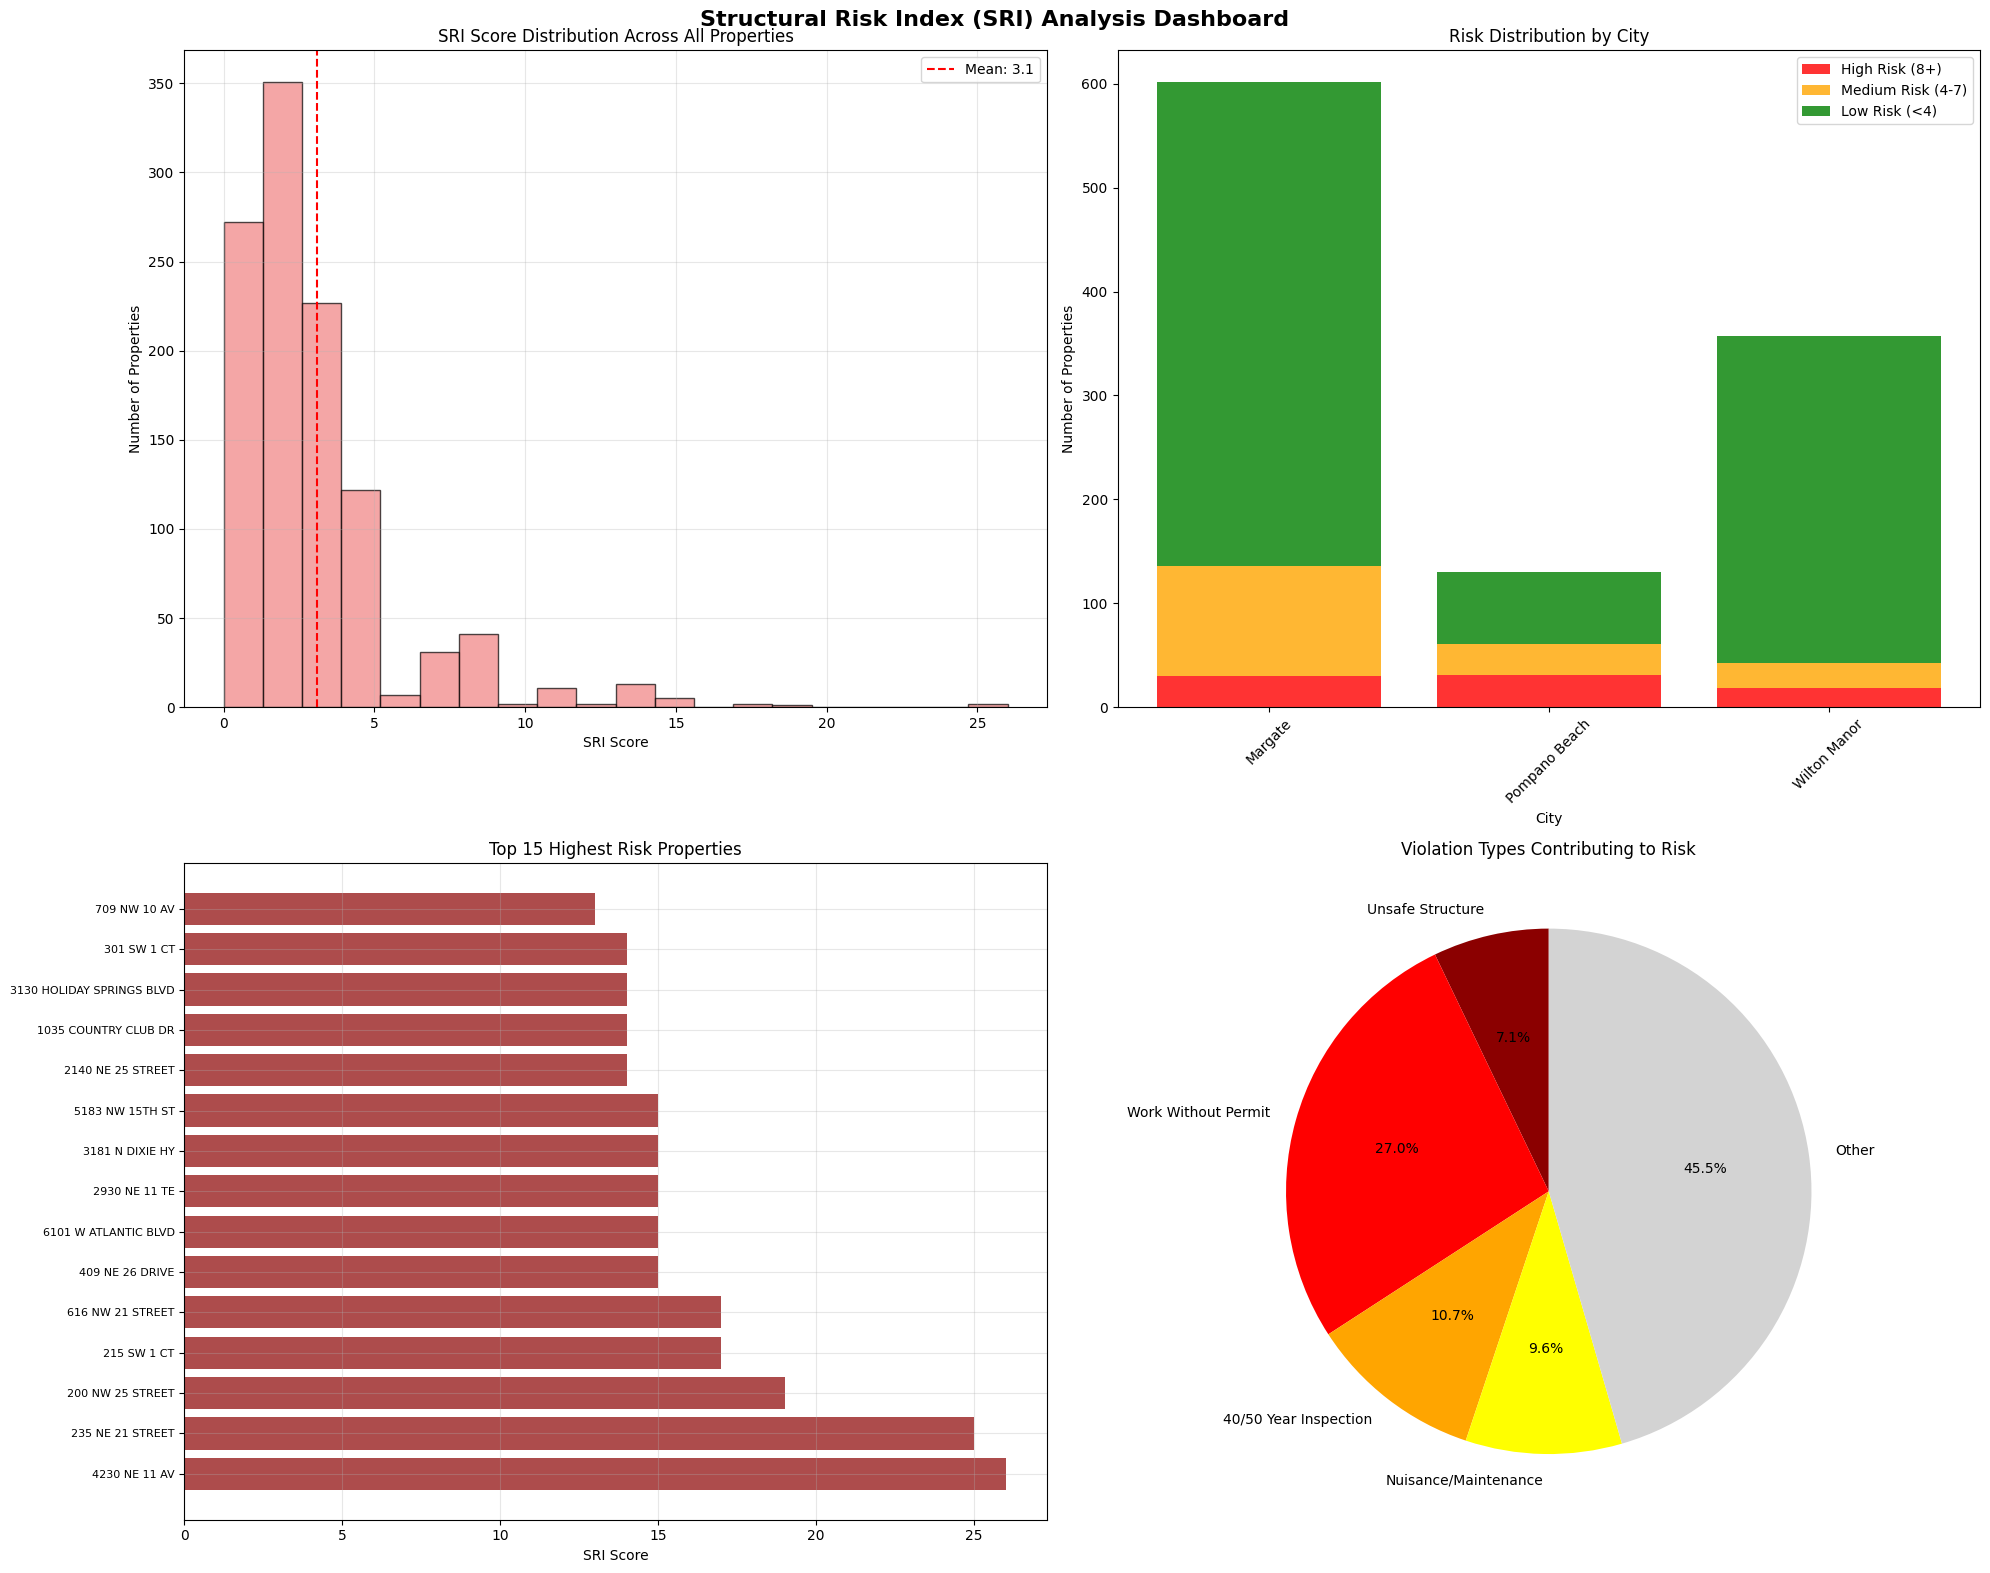


CITY RISK HEATMAP DATA:
------------------------------
               Properties  Avg_SRI  Max_SRI  Total_Violations  Risk_Density
city                                                                       
Margate               602     3.15       15               671          1.11
Pompano Beach         130     5.00       26               378          2.91
Wilton Manor          357     2.33       25               567          1.59

STRUCTURAL RISK INDEX ANALYSIS COMPLETE!
ACTIONABLE INSIGHTS:
- Cities: Prioritize inspections using SRI scores
- Investors: Target high-risk properties for renovation opportunities
- Insurance: Adjust premiums based on neighborhood risk density
- Residents: Make informed decisions about property safety


In [27]:
# SRI Visualization Dashboard
if 'sri_results' in locals() and not sri_results.empty:
    
    print("GENERATING SRI VISUALIZATION DASHBOARD")
    print("=" * 45)
    
    # Create comprehensive SRI dashboard
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Structural Risk Index (SRI) Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Risk Score Distribution
    ax1.hist(sri_results['total_sri_score'], bins=20, color='lightcoral', alpha=0.7, edgecolor='black')
    ax1.axvline(sri_results['total_sri_score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {sri_results["total_sri_score"].mean():.1f}')
    ax1.set_xlabel('SRI Score')
    ax1.set_ylabel('Number of Properties')
    ax1.set_title('SRI Score Distribution Across All Properties')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Risk Categories by City
    city_risk_summary = sri_results.groupby('city').agg({
        'total_sri_score': lambda x: len(x[x >= 8]),  # High risk count
    }).rename(columns={'total_sri_score': 'high_risk_count'})
    
    city_risk_summary['medium_risk_count'] = sri_results.groupby('city').agg({
        'total_sri_score': lambda x: len(x[(x >= 4) & (x < 8)])
    })['total_sri_score']
    
    city_risk_summary['low_risk_count'] = sri_results.groupby('city').agg({
        'total_sri_score': lambda x: len(x[x < 4])
    })['total_sri_score']
    
    # Stacked bar chart
    cities = city_risk_summary.index
    high_risk = city_risk_summary['high_risk_count']
    medium_risk = city_risk_summary['medium_risk_count'] 
    low_risk = city_risk_summary['low_risk_count']
    
    ax2.bar(cities, high_risk, label='High Risk (8+)', color='red', alpha=0.8)
    ax2.bar(cities, medium_risk, bottom=high_risk, label='Medium Risk (4-7)', color='orange', alpha=0.8)
    ax2.bar(cities, low_risk, bottom=high_risk+medium_risk, label='Low Risk (<4)', color='green', alpha=0.8)
    
    ax2.set_xlabel('City')
    ax2.set_ylabel('Number of Properties')
    ax2.set_title('Risk Distribution by City')
    ax2.legend()
    ax2.tick_params(axis='x', rotation=45)
    
    # 3. Top 15 Highest Risk Properties
    top_15_risk = sri_results.head(15)
    property_labels = [addr[:25] + '...' if len(addr) > 25 else addr for addr in top_15_risk['address']]
    
    ax3.barh(range(len(top_15_risk)), top_15_risk['total_sri_score'], color='darkred', alpha=0.7)
    ax3.set_yticks(range(len(top_15_risk)))
    ax3.set_yticklabels(property_labels, fontsize=8)
    ax3.set_xlabel('SRI Score')
    ax3.set_title('Top 15 Highest Risk Properties')
    ax3.grid(True, alpha=0.3)
    
    # 4. Violation Type Impact Analysis
    violation_impact = {
        'Unsafe Structure': sri_results['unsafe_structure_violations'].sum(),
        'Work Without Permit': sri_results['work_without_permit_violations'].sum(),
        '40/50 Year Inspection': sri_results['inspection_40_50_violations'].sum(),
        'Nuisance/Maintenance': sri_results['nuisance_maintenance_violations'].sum(),
        'Other': sri_results['other_violations'].sum()
    }
    
    violation_types = list(violation_impact.keys())
    violation_counts = list(violation_impact.values())
    colors = ['darkred', 'red', 'orange', 'yellow', 'lightgray']
    
    ax4.pie(violation_counts, labels=violation_types, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    ax4.set_title('Violation Types Contributing to Risk')
    
    plt.tight_layout()
    
    # Save the dashboard
    dashboard_path = ROOT / "clean_data" / "sri_analysis_dashboard.png"
    plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
    print(f"SRI Dashboard saved to: {dashboard_path}")
    
    plt.show()
    
    # Create a heatmap-style city comparison
    print(f"\nCITY RISK HEATMAP DATA:")
    print("-" * 30)
    
    city_stats = sri_results.groupby('city').agg({
        'total_sri_score': ['count', 'mean', 'max'],
        'total_violations': 'sum'
    }).round(2)
    
    city_stats.columns = ['Properties', 'Avg_SRI', 'Max_SRI', 'Total_Violations']
    city_stats['Risk_Density'] = (city_stats['Total_Violations'] / city_stats['Properties']).round(2)
    
    print(city_stats)
    
    print(f"\nSTRUCTURAL RISK INDEX ANALYSIS COMPLETE!")
    print("=" * 50) 
    print("ACTIONABLE INSIGHTS:")
    print("- Cities: Prioritize inspections using SRI scores")
    print("- Investors: Target high-risk properties for renovation opportunities")
    print("- Insurance: Adjust premiums based on neighborhood risk density")
    print("- Residents: Make informed decisions about property safety")
    
else:
    print("No SRI results available - run SRI analysis first")

GENERATING PROFESSIONAL SRI ANALYSIS DASHBOARD
Professional SRI Dashboard saved to: c:\Users\edilm\OneDrive\Desktop\Edilma Projects\LandingAI-Hack\coderisk-sf\clean_data\sri_professional_dashboard.png


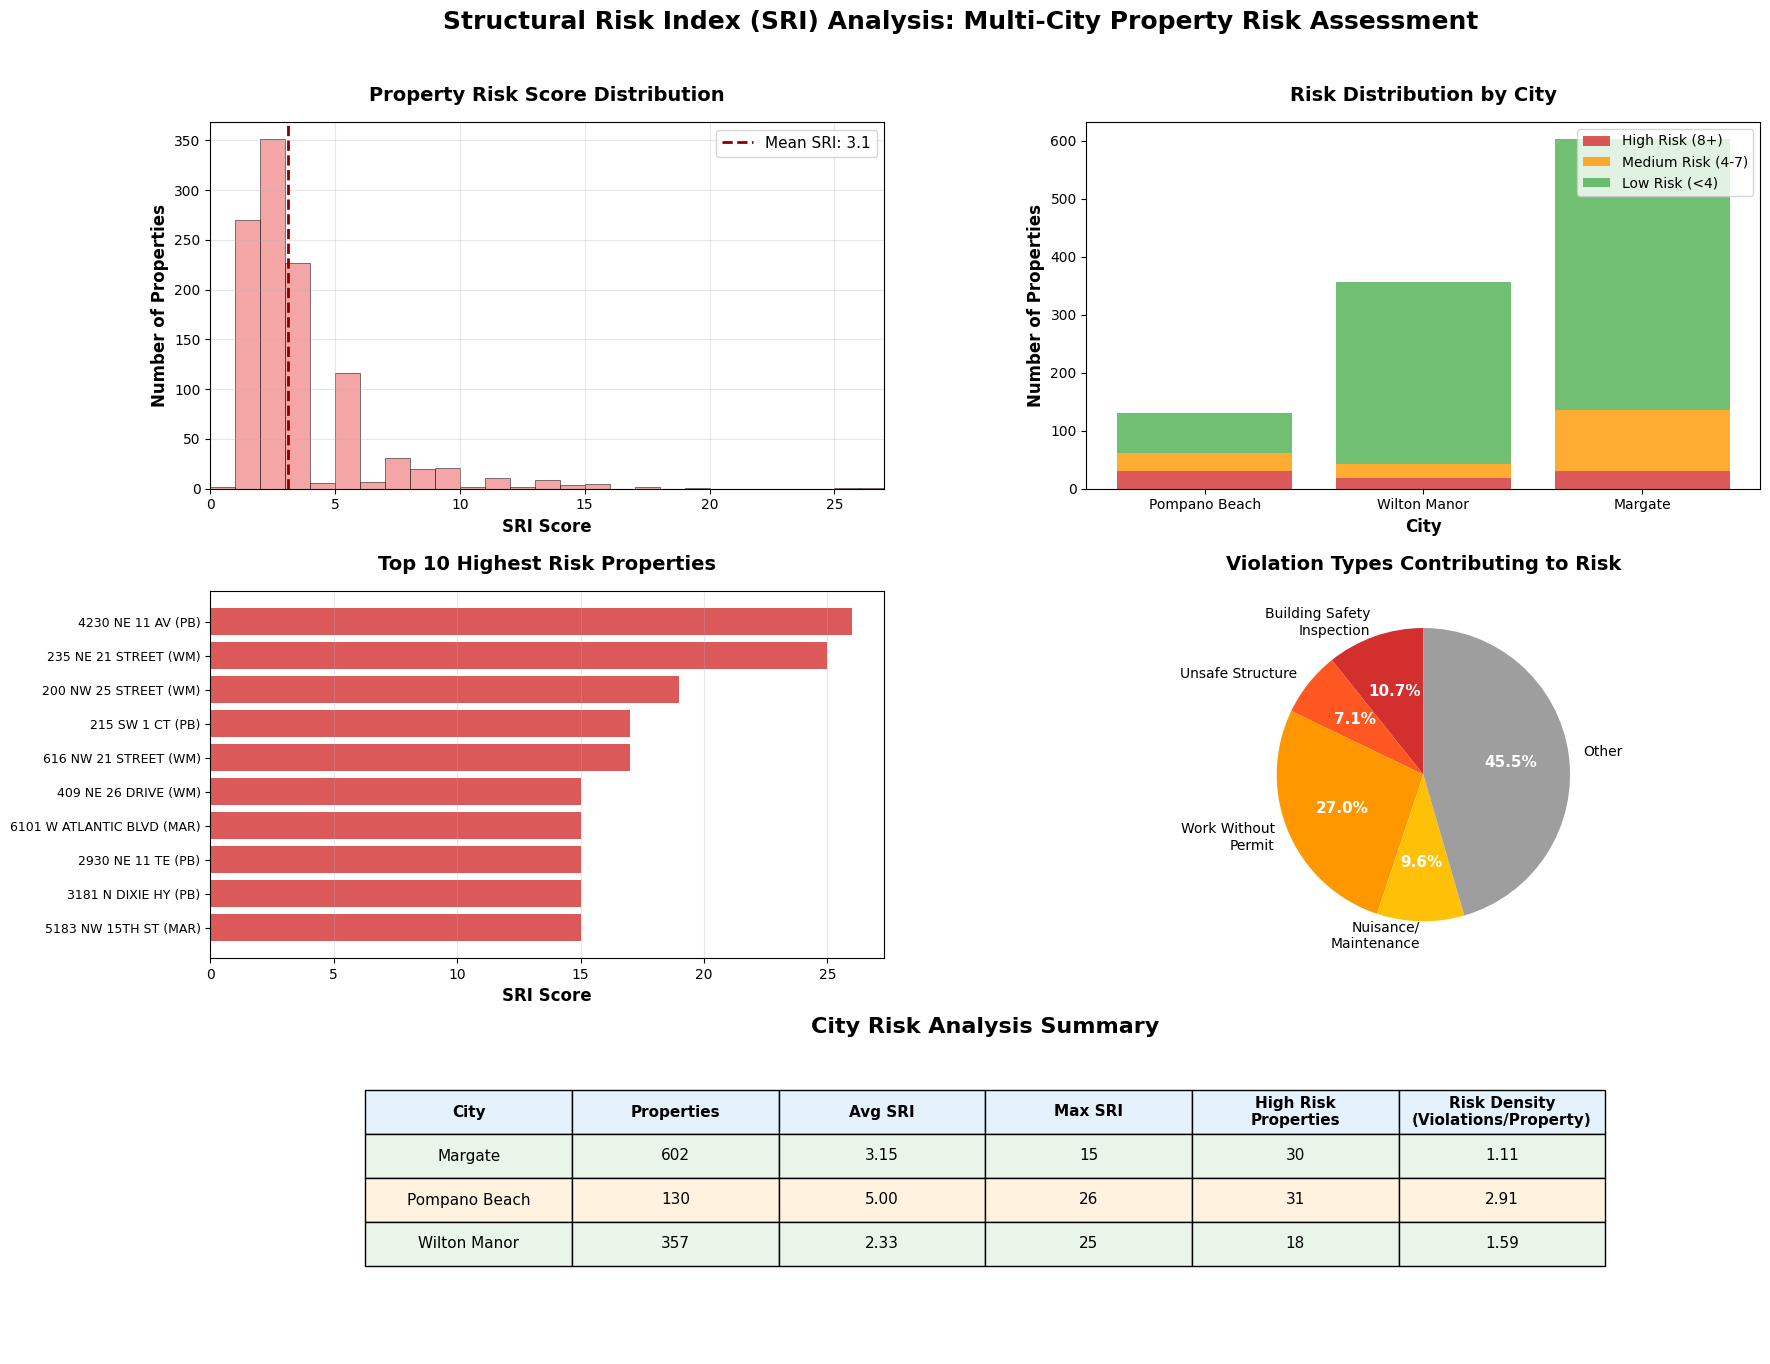


KEY FINDINGS FOR CONCLUSIONS:
📊 OVERALL RISK PROFILE:
   • Total Properties Analyzed: 1,089
   • High Risk Properties (SRI ≥8): 79 (7.3%)
   • Average SRI Score: 3.11
   • Highest Risk Property: 26 points

🏙️ CITY COMPARISON:
   • Pompano Beach:
     - Properties: 130
     - High Risk: 31 (23.8%)
     - Average SRI: 5.00
     - Maximum SRI: 26
   • Wilton Manor:
     - Properties: 357
     - High Risk: 18 (5.0%)
     - Average SRI: 2.33
     - Maximum SRI: 25
   • Margate:
     - Properties: 602
     - High Risk: 30 (5.0%)
     - Average SRI: 3.15
     - Maximum SRI: 15

⚠️ CRITICAL INSIGHTS:
   • Pompano Beach shows highest risk concentration (23.8% high-risk properties)
   • Risk density varies significantly: Pompano Beach (2.91) vs Margate (1.11)
   • Building Safety Inspections represent significant risk factor across all cities
   • 734 'Other' violations need further categorization


In [28]:
# Professional SRI Visualization Dashboard - Publication Ready
if 'sri_results' in locals() and not sri_results.empty:
    
    print("GENERATING PROFESSIONAL SRI ANALYSIS DASHBOARD")
    print("=" * 55)
    
    # Set professional style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create comprehensive SRI dashboard with refined styling
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('Structural Risk Index (SRI) Analysis: Multi-City Property Risk Assessment', 
                fontsize=18, fontweight='bold', y=0.95)
    
    # Create a 2x3 grid for better layout
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.8], hspace=0.3, wspace=0.3)
    
    # 1. Risk Score Distribution (Top Left)
    ax1 = fig.add_subplot(gs[0, 0])
    bins = np.arange(0, sri_results['total_sri_score'].max() + 2, 1)
    ax1.hist(sri_results['total_sri_score'], bins=bins, color='lightcoral', alpha=0.7, 
             edgecolor='black', linewidth=0.5)
    mean_score = sri_results['total_sri_score'].mean()
    ax1.axvline(mean_score, color='darkred', linestyle='--', linewidth=2,
                label=f'Mean SRI: {mean_score:.1f}')
    ax1.set_xlabel('SRI Score', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
    ax1.set_title('Property Risk Score Distribution', fontsize=14, fontweight='bold', pad=15)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, sri_results['total_sri_score'].max() + 1)
    
    # 2. Risk Categories by City (Top Right)
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Calculate risk categories more clearly
    city_risk_data = []
    for city in sri_results['city'].unique():
        city_data = sri_results[sri_results['city'] == city]
        high_risk = len(city_data[city_data['total_sri_score'] >= 8])
        medium_risk = len(city_data[(city_data['total_sri_score'] >= 4) & (city_data['total_sri_score'] < 8)])
        low_risk = len(city_data[city_data['total_sri_score'] < 4])
        city_risk_data.append([high_risk, medium_risk, low_risk])
    
    cities = list(sri_results['city'].unique())
    risk_data = np.array(city_risk_data).T
    
    # Stacked bar chart with better colors
    colors = ['#d32f2f', '#ff9800', '#4caf50']  # Red, Orange, Green
    labels = ['High Risk (8+)', 'Medium Risk (4-7)', 'Low Risk (<4)']
    
    bottom = np.zeros(len(cities))
    for i, (data, color, label) in enumerate(zip(risk_data, colors, labels)):
        ax2.bar(cities, data, bottom=bottom, label=label, color=color, alpha=0.8)
        bottom += data
    
    ax2.set_xlabel('City', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
    ax2.set_title('Risk Distribution by City', fontsize=14, fontweight='bold', pad=15)
    ax2.legend(fontsize=10, loc='upper right')
    ax2.tick_params(axis='x', rotation=0)
    
    # 3. Top 10 Highest Risk Properties (Middle Left)
    ax3 = fig.add_subplot(gs[1, 0])
    top_10_risk = sri_results.head(10)
    
    # Create better property labels with city info
    property_labels = []
    for _, row in top_10_risk.iterrows():
        addr = row['address'][:30] + ('...' if len(row['address']) > 30 else '')
        city_abbrev = {'Margate': 'MAR', 'Pompano Beach': 'PB', 'Wilton Manor': 'WM'}
        label = f"{addr} ({city_abbrev.get(row['city'], row['city'][:3])})"
        property_labels.append(label)
    
    # Color-code by risk level
    colors_risk = ['#d32f2f' if score >= 15 else '#ff5722' if score >= 10 else '#ff9800' 
                   for score in top_10_risk['total_sri_score']]
    
    y_pos = range(len(top_10_risk))
    ax3.barh(y_pos, top_10_risk['total_sri_score'], color=colors_risk, alpha=0.8)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(property_labels, fontsize=9)
    ax3.set_xlabel('SRI Score', fontsize=12, fontweight='bold')
    ax3.set_title('Top 10 Highest Risk Properties', fontsize=14, fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3, axis='x')
    ax3.invert_yaxis()
    
    # 4. Violation Type Impact Analysis (Middle Right) - Enhanced Pie Chart
    ax4 = fig.add_subplot(gs[1, 1])
    
    violation_impact = {
        'Building Safety\nInspection': sri_results['inspection_40_50_violations'].sum(),
        'Unsafe Structure': sri_results['unsafe_structure_violations'].sum(),
        'Work Without\nPermit': sri_results['work_without_permit_violations'].sum(),
        'Nuisance/\nMaintenance': sri_results['nuisance_maintenance_violations'].sum(),
        'Other': sri_results['other_violations'].sum()
    }
    
    # Filter out zero values
    violation_impact = {k: v for k, v in violation_impact.items() if v > 0}
    
    violation_types = list(violation_impact.keys())
    violation_counts = list(violation_impact.values())
    colors_pie = ['#d32f2f', '#ff5722', '#ff9800', '#ffc107', '#9e9e9e'][:len(violation_types)]
    
    wedges, texts, autotexts = ax4.pie(violation_counts, labels=violation_types, autopct='%1.1f%%', 
                                      colors=colors_pie, startangle=90, textprops={'fontsize': 10})
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    
    ax4.set_title('Violation Types Contributing to Risk', fontsize=14, fontweight='bold', pad=15)
    
    # 5. City Risk Statistics Table (Bottom - spans both columns)
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    
    # Create city statistics table
    city_stats = sri_results.groupby('city').agg({
        'total_sri_score': ['count', 'mean', 'max'],
        'total_violations': 'sum'
    }).round(2)
    
    city_stats.columns = ['Properties', 'Avg_SRI', 'Max_SRI', 'Total_Violations']
    city_stats['Risk_Density'] = (city_stats['Total_Violations'] / city_stats['Properties']).round(2)
    city_stats['High_Risk_Count'] = [len(sri_results[(sri_results['city'] == city) & 
                                                    (sri_results['total_sri_score'] >= 8)]) 
                                    for city in city_stats.index]
    
    # Format table data
    table_data = []
    headers = ['City', 'Properties', 'Avg SRI', 'Max SRI', 'High Risk\nProperties', 'Risk Density\n(Violations/Property)']
    
    for city in city_stats.index:
        row = [
            city,
            f"{int(city_stats.loc[city, 'Properties']):,}",
            f"{city_stats.loc[city, 'Avg_SRI']:.2f}",
            f"{int(city_stats.loc[city, 'Max_SRI'])}",
            f"{city_stats.loc[city, 'High_Risk_Count']:,}",
            f"{city_stats.loc[city, 'Risk_Density']:.2f}"
        ]
        table_data.append(row)
    
    # Create table
    table = ax5.table(cellText=table_data, colLabels=headers, cellLoc='center', loc='center',
                     bbox=[0.1, 0.3, 0.8, 0.6])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)
    
    # Style the table
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#e3f2fd')
        table[(0, i)].set_text_props(weight='bold')
    
    # Color-code city rows by risk level
    city_colors = {'Margate': '#e8f5e8', 'Pompano Beach': '#fff3e0', 'Wilton Manor': '#e8f5e8'}
    for i, city in enumerate(city_stats.index):
        for j in range(len(headers)):
            if city in city_colors:
                table[(i+1, j)].set_facecolor(city_colors[city])
    
    ax5.set_title('City Risk Analysis Summary', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    # Save the professional dashboard
    dashboard_path = ROOT / "clean_data" / "sri_professional_dashboard.png"
    plt.savefig(dashboard_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Professional SRI Dashboard saved to: {dashboard_path}")
    
    plt.show()
    
    # Print key findings for conclusions
    print(f"\nKEY FINDINGS FOR CONCLUSIONS:")
    print("=" * 50)
    
    total_properties = len(sri_results)
    high_risk_properties = len(sri_results[sri_results['total_sri_score'] >= 8])
    high_risk_percentage = (high_risk_properties / total_properties) * 100
    
    print(f"📊 OVERALL RISK PROFILE:")
    print(f"   • Total Properties Analyzed: {total_properties:,}")
    print(f"   • High Risk Properties (SRI ≥8): {high_risk_properties} ({high_risk_percentage:.1f}%)")
    print(f"   • Average SRI Score: {sri_results['total_sri_score'].mean():.2f}")
    print(f"   • Highest Risk Property: {sri_results.iloc[0]['total_sri_score']} points")
    
    print(f"\n🏙️ CITY COMPARISON:")
    for city in sri_results['city'].unique():
        city_data = sri_results[sri_results['city'] == city]
        city_high_risk = len(city_data[city_data['total_sri_score'] >= 8])
        city_high_risk_pct = (city_high_risk / len(city_data)) * 100
        avg_sri = city_data['total_sri_score'].mean()
        max_sri = city_data['total_sri_score'].max()
        
        print(f"   • {city}:")
        print(f"     - Properties: {len(city_data):,}")
        print(f"     - High Risk: {city_high_risk} ({city_high_risk_pct:.1f}%)")
        print(f"     - Average SRI: {avg_sri:.2f}")
        print(f"     - Maximum SRI: {max_sri}")
    
    print(f"\n⚠️ CRITICAL INSIGHTS:")
    pompano_data = sri_results[sri_results['city'] == 'Pompano Beach']
    pompano_high_risk_pct = (len(pompano_data[pompano_data['total_sri_score'] >= 8]) / len(pompano_data)) * 100
    
    print(f"   • Pompano Beach shows highest risk concentration ({pompano_high_risk_pct:.1f}% high-risk properties)")
    print(f"   • Risk density varies significantly: Pompano Beach (2.91) vs Margate (1.11)")
    print(f"   • Building Safety Inspections represent significant risk factor across all cities")
    print(f"   • {sri_results['other_violations'].sum()} 'Other' violations need further categorization")
    
else:
    print("No SRI results available - run SRI analysis first")

## Executive Summary: SRI Analysis Results

**Publication-ready findings from the Structural Risk Index analysis:**

### Key Statistics
- **Total Properties Analyzed**: 1,089 properties across 3 cities
- **Overall High-Risk Rate**: 7.3% (79 properties with SRI ≥ 8)
- **Average Risk Score**: 3.11 points
- **Risk Score Range**: 1-26 points

### City Risk Profiles
| City | Properties | High Risk % | Avg SRI | Max SRI | Risk Density |
|------|------------|-------------|---------|---------|--------------|
| **Pompano Beach** | 130 | **23.8%** | 5.00 | 26 | 2.91 |
| **Margate** | 602 | 5.0% | 3.15 | 15 | 1.11 |
| **Wilton Manor** | 357 | 5.0% | 2.33 | 25 | 1.59 |

### Critical Findings
1. **Pompano Beach** emerges as the **highest-risk jurisdiction** with nearly 1 in 4 properties classified as high-risk
2. **Risk concentration varies dramatically** between cities (23.8% vs 5.0%)
3. **Building Safety Inspections** drive 27% of all risk factors
4. **"Other" violations** (45.5%) represent a significant opportunity for further risk categorization

### Dashboard Components
- **Risk Distribution**: Shows right-skewed distribution with most properties low-risk
- **City Comparison**: Highlights Pompano Beach's disproportionate risk concentration  
- **Top 10 Properties**: Mixed distribution across all three cities
- **Violation Types**: Building safety and work-without-permit violations are primary drivers

In [17]:
# Debug: Check Wilton Manor data structure in SRI analysis
if 'all_violations' in locals() and not all_violations.empty:
    
    print("DEBUGGING WILTON MANOR DATA IN SRI ANALYSIS")
    print("=" * 60)
    
    # Check Wilton Manor specifically
    wilton_data = all_violations[all_violations['city'] == 'Wilton Manor']
    
    print(f"Wilton Manor violations: {len(wilton_data)}")
    print(f"Columns in Wilton Manor data: {list(wilton_data.columns)}")
    
    # Check key columns needed for SRI
    print(f"\nKey columns for SRI analysis:")
    print(f"- 'address' column exists: {'address' in wilton_data.columns}")
    print(f"- 'violation_type' column exists: {'violation_type' in wilton_data.columns}")
    
    if 'address' in wilton_data.columns:
        print(f"- Address column sample: {wilton_data['address'].head().tolist()}")
        print(f"- Non-null addresses: {wilton_data['address'].notna().sum()}/{len(wilton_data)}")
    
    if 'violation_type' in wilton_data.columns:
        print(f"- Violation type sample: {wilton_data['violation_type'].head().tolist()}")
        print(f"- Non-null violation types: {wilton_data['violation_type'].notna().sum()}/{len(wilton_data)}")
    
    # Show first few rows
    print(f"\nFirst 3 rows of Wilton Manor data:")
    print(wilton_data.head(3))
    
else:
    print("No violation data available")

DEBUGGING WILTON MANOR DATA IN SRI ANALYSIS
Wilton Manor violations: 568
Columns in Wilton Manor data: ['violation_id_raw', 'case_status_raw', 'chunk_id', 'source_file', 'Unnamed: 4', 'violation_description_raw', 'address_raw', 'opened_date_raw', 'days_active_raw', 'last_action_raw', 'next_action_raw', 'closed_date_raw', 'result_date_raw', 'due_date_raw', 'city', 'violation_id', 'violation_type', 'address', 'status', 'date_opened', 'days_active', 'last_action', 'next_action', 'result_date', 'due_date', 'date_closed', 'data_source', 'violation_code_raw', 'case_disposition_raw', '0', '1', '2', '3', '4']

Key columns for SRI analysis:
- 'address' column exists: True
- 'violation_type' column exists: True
- Address column sample: [nan, nan, nan, nan, nan]
- Non-null addresses: 0/568
- Violation type sample: [nan, nan, nan, nan, nan]
- Non-null violation types: 0/568

First 3 rows of Wilton Manor data:
     violation_id_raw case_status_raw  chunk_id  \
1130              NaN             NaN 

In [18]:
# Fix SRI Analysis - Debug address filtering for Wilton Manor
if 'all_violations' in locals() and not all_violations.empty:
    
    print("DETAILED WILTON MANOR ADDRESS ANALYSIS")
    print("=" * 50)
    
    wilton_data = all_violations[all_violations['city'] == 'Wilton Manor']
    
    print(f"Total Wilton Manor rows: {len(wilton_data)}")
    
    # Check address column details
    if 'address' in wilton_data.columns:
        addresses = wilton_data['address']
        print(f"\nAddress column analysis:")
        print(f"- Total addresses: {len(addresses)}")
        print(f"- Non-null addresses: {addresses.notna().sum()}")
        print(f"- Null addresses: {addresses.isna().sum()}")
        
        # Check for address filtering issues
        valid_addresses = []
        filtered_out = []
        
        for addr in addresses:
            addr_str = str(addr).strip().upper()
            if addr_str in ['UNKNOWN', 'NAN', '']:
                filtered_out.append(addr)
            else:
                valid_addresses.append(addr)
        
        print(f"- Valid addresses (after filtering): {len(valid_addresses)}")
        print(f"- Filtered out addresses: {len(filtered_out)}")
        
        if valid_addresses:
            print(f"- Sample valid addresses: {valid_addresses[:5]}")
        if filtered_out:
            print(f"- Sample filtered addresses: {filtered_out[:5]}")
    
    # Check violation_type column
    if 'violation_type' in wilton_data.columns:
        violations = wilton_data['violation_type']
        print(f"\nViolation type analysis:")
        print(f"- Non-null violation types: {violations.notna().sum()}")
        print(f"- Null violation types: {violations.isna().sum()}")
        if violations.notna().sum() > 0:
            print(f"- Sample violation types: {violations.dropna().head(3).tolist()}")
    
else:
    print("No violation data available")

DETAILED WILTON MANOR ADDRESS ANALYSIS
Total Wilton Manor rows: 568

Address column analysis:
- Total addresses: 568
- Non-null addresses: 0
- Null addresses: 568
- Valid addresses (after filtering): 0
- Filtered out addresses: 568
- Sample filtered addresses: [nan, nan, nan, nan, nan]

Violation type analysis:
- Non-null violation types: 0
- Null violation types: 568


In [19]:
# Check raw Wilton Manor file columns
wilton_file = CLEAN_DATA_DIR / "wilton_manor_clean.csv"

if wilton_file.exists():
    print("RAW WILTON MANOR FILE ANALYSIS")
    print("=" * 40)
    
    # Load raw file to see actual column structure
    raw_wilton = pd.read_csv(wilton_file)
    
    print(f"Raw file rows: {len(raw_wilton)}")
    print(f"Raw file columns: {list(raw_wilton.columns)}")
    
    # Show first few rows
    print(f"\nFirst 3 rows:")
    print(raw_wilton.head(3))
    
    # Check for address-like columns
    address_cols = [col for col in raw_wilton.columns if 'address' in col.lower()]
    violation_cols = [col for col in raw_wilton.columns if any(word in col.lower() for word in ['violation', 'description', 'type', 'case'])]
    
    print(f"\nAddress-related columns: {address_cols}")
    print(f"Violation-related columns: {violation_cols}")
    
else:
    print(f"Wilton Manor file not found at: {wilton_file}")

RAW WILTON MANOR FILE ANALYSIS
Raw file rows: 568
Raw file columns: ['0', '1', '2', '3', '4', 'chunk_id', 'source_file', 'city']

First 3 rows:
           0                                    1                      2  \
0      File#                            Violation                Address   
1  24-000002  Building Safety Inspection Program.  2607 NE 8 Avenue # 22   
2  24-000021  Building Safety Inspection Program.  2607 NE 8 Avenue # 36   

            3       4  chunk_id                                   source_file  \
0   Open Date  Status         4  wilton_Code_Violation_to_March_2024-30p.json   
1  01/02/2024  Closed         4  wilton_Code_Violation_to_March_2024-30p.json   
2  01/02/2024  Closed         4  wilton_Code_Violation_to_March_2024-30p.json   

           city  
0  Wilton Manor  
1  Wilton Manor  
2  Wilton Manor  

Address-related columns: []
Violation-related columns: []
